### Insights and Error Analysis 

In [11]:

import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

os.makedirs('../outputs', exist_ok=True)

COLORS = {'Positive': '#1D9E75', 'Neutral': '#EF9F27', 'Negative': '#E24B4A'}
LABEL_MAP   = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}
LABEL_ORDER = ['Negative', 'Neutral', 'Positive']

with open('../models/lr_tuned.pkl', 'rb') as f:
    best_model = pickle.load(f)
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

df = pd.read_csv('../data/reviews_preprocessed.csv')
if 'sentiment' not in df.columns:
    def map_sentiment(s):
        if s >= 4: return 'Positive'
        elif s == 3: return 'Neutral'
        return 'Negative'
    df['sentiment'] = df['Score'].apply(map_sentiment)

label_map_int = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['label'] = df['sentiment'].map(label_map_int)
df['lemmatized'] = df['lemmatized'].fillna('')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['lemmatized'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

_, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_test = df_test.reset_index(drop=True)

X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
y_pred       = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

print(f"Test samples : {len(y_test):,}")
print(f"Overall Acc  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print("✅ Setup complete")

Test samples : 10,000
Overall Acc  : 0.8163
F1 Macro     : 0.6271
✅ Setup complete


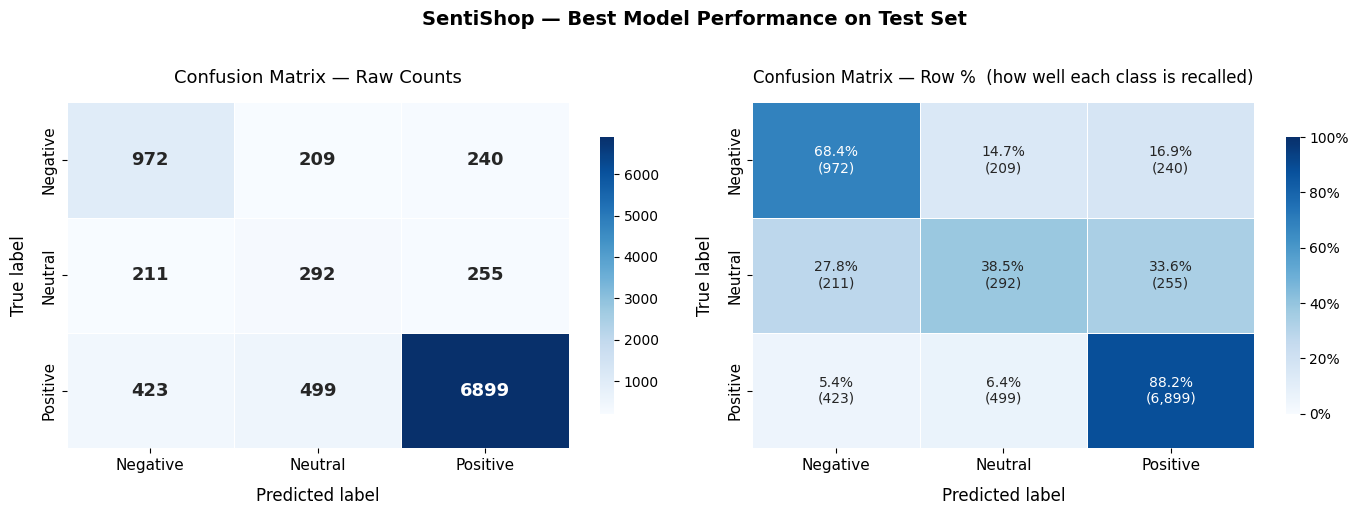


Per-class recall (diagonal %):
  Negative  : 68.4%
  Neutral   : 38.5%
  Positive  : 88.2%


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw counts ────────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', ax=axes[0],
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    cmap='Blues', linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 13, 'weight': 'bold'},
)
axes[0].set_xlabel('Predicted label', fontsize=12, labelpad=10)
axes[0].set_ylabel('True label',      fontsize=12, labelpad=10)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, pad=14)
axes[0].tick_params(axis='both', labelsize=11)

# ── Right: row-normalised percentages ───────────────────────────
annot_labels = np.array([
    [f'{cm_pct[r,c]:.1f}%\n({cm[r,c]:,})'
     for c in range(3)] for r in range(3)
])
sns.heatmap(
    cm_pct, annot=annot_labels, fmt='', ax=axes[1],
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    cmap='Blues', linewidths=0.5, linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'shrink': 0.8, 'format': '%.0f%%'},
    annot_kws={'size': 10},
)
axes[1].set_xlabel('Predicted label', fontsize=12, labelpad=10)
axes[1].set_ylabel('True label',      fontsize=12, labelpad=10)
axes[1].set_title('Confusion Matrix — Row %  (how well each class is recalled)',
                  fontsize=12, pad=14)
axes[1].tick_params(axis='both', labelsize=11)

plt.suptitle('SentiShop — Best Model Performance on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/final_confusion_matrix.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Print diagonal recall per class
print("\nPer-class recall (diagonal %):")
for i, name in enumerate(LABEL_ORDER):
    print(f"  {name:10s}: {cm_pct[i,i]:.1f}%")

In [13]:
# Attach predictions and confidence to test rows
df_test = df_test.copy()
df_test['y_true']      = y_test.values
df_test['y_pred']      = y_pred
df_test['correct']     = df_test['y_true'] == df_test['y_pred']
df_test['true_label']  = df_test['y_true'].map(LABEL_MAP)
df_test['pred_label']  = df_test['y_pred'].map(LABEL_MAP)
df_test['confidence']  = y_pred_proba.max(axis=1)

# All misclassified rows
errors = df_test[~df_test['correct']].copy()
errors['error_type'] = errors['true_label'] + ' → ' + errors['pred_label']

print(f"Total errors   : {len(errors):,} / {len(df_test):,}  "
      f"({len(errors)/len(df_test)*100:.1f}%)")
print(f"\nError breakdown by type:")
print(errors['error_type'].value_counts().to_string())


Total errors   : 1,837 / 10,000  (18.4%)

Error breakdown by type:
error_type
Positive → Neutral     499
Positive → Negative    423
Neutral → Positive     255
Negative → Positive    240
Neutral → Negative     211
Negative → Neutral     209


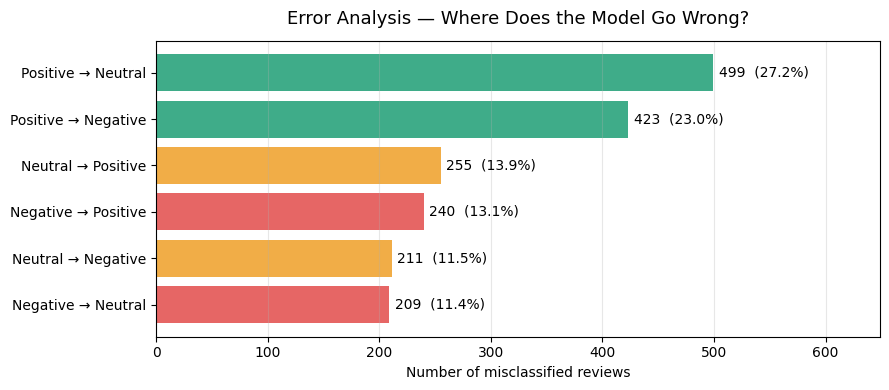

In [14]:

error_counts = errors['error_type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = []
for etype in error_counts.index:
    true_class = etype.split(' → ')[0]
    bar_colors.append(COLORS[true_class])

bars = ax.barh(error_counts.index, error_counts.values,
               color=bar_colors, alpha=0.85, edgecolor='none')

for bar, val in zip(bars, error_counts.values):
    pct = val / len(errors) * 100
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('Number of misclassified reviews')
ax.set_title('Error Analysis — Where Does the Model Go Wrong?',
             fontsize=13, pad=12)
ax.set_xlim(0, error_counts.max() * 1.3)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/error_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

### Testing the model 


In [15]:
import pickle, re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

with open('../models/lr_tuned.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

SW = set(stopwords.words('english'))  # build once, not inside the function

def predict(text):
    clean_text = re.sub(r'[^a-z\s]', ' ', text.lower())
    clean_text = ' '.join([w for w in clean_text.split() if w not in SW])
    pred = model.predict(vectorizer.transform([clean_text]))[0]
    return {2: 'Positive', 1: 'Neutral', 0: 'Negative'}[pred]

print(predict("This product is absolutely amazing!"))
print(predict("Terrible quality, do not buy."))

Positive
Negative


In [16]:
import os
print("lr_tuned.pkl last modified:", os.path.getmtime('../models/lr_tuned.pkl'))
print("Current time:             ", __import__('time').time())

lr_tuned.pkl last modified: 1782796558.281443
Current time:              1782797258.3995333


In [17]:
# import os
# files_to_check = [
#     '../outputs/final_confusion_matrix.png',
#     '../outputs/error_analysis.png',
#     '../outputs/final_summary.png',
# ]
# for f in files_to_check:
#     exists = os.path.exists(f)
#     print(f"{'✅' if exists else '❌'} {f}")

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

os.makedirs('../outputs', exist_ok=True)

COLORS = {'Positive': '#1D9E75', 'Neutral': '#EF9F27', 'Negative': '#E24B4A'}
LABEL_MAP   = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}
LABEL_ORDER = ['Negative', 'Neutral', 'Positive']

with open('../models/lr_tuned.pkl', 'rb') as f:
    best_model = pickle.load(f)
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

df = pd.read_csv('../data/reviews_preprocessed.csv')
if 'sentiment' not in df.columns:
    def map_sentiment(s):
        if s >= 4: return 'Positive'
        elif s == 3: return 'Neutral'
        return 'Negative'
    df['sentiment'] = df['Score'].apply(map_sentiment)

label_map_int = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['label'] = df['sentiment'].map(label_map_int)
df['lemmatized'] = df['lemmatized'].fillna('')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['lemmatized'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

_, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
df_test = df_test.reset_index(drop=True)

X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
y_pred       = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

print(f"Test samples : {len(y_test):,}")
print(f"Overall Acc  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred, average='macro'):.4f}")
print("✅ Setup complete")

Test samples : 10,000
Overall Acc  : 0.8163
F1 Macro     : 0.6271
✅ Setup complete


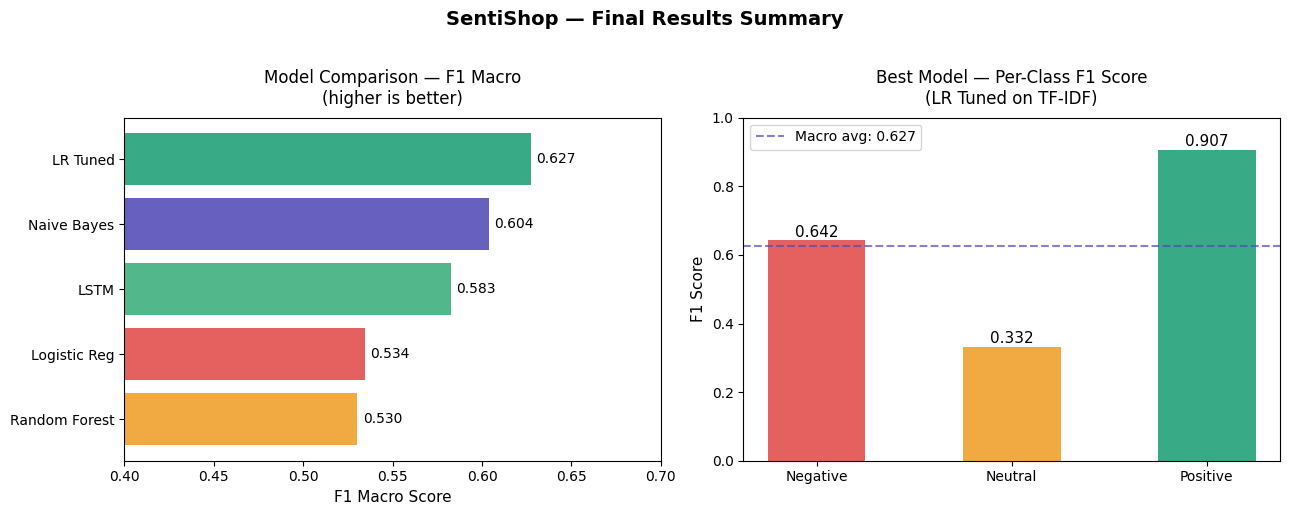


✅ Week  notebook complete!


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

results_data = {
    'Model':       ['LR Tuned', 'Naive Bayes', 'Logistic Reg',
                    'Random Forest', 'LSTM'],
    'Accuracy':    [0.8163, 0.8139, 0.7039, 0.8353, 0.8407],
    'F1 Macro':    [0.6271, 0.6037, 0.5345, 0.5303, 0.5825],
}

results_df = pd.DataFrame(results_data).sort_values('F1 Macro', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

model_colors = ['#EF9F27','#E24B4A','#3aad7a','#534AB7','#1D9E75']

axes[0].barh(results_df['Model'], results_df['F1 Macro'],
             color=model_colors, alpha=0.88, edgecolor='none')
axes[0].set_xlim(0.4, 0.70)
axes[0].set_xlabel('F1 Macro Score', fontsize=11)
axes[0].set_title('Model Comparison — F1 Macro\n(higher is better)',
                  fontsize=12, pad=10)
for i, (_, row) in enumerate(results_df.iterrows()):
    axes[0].text(row['F1 Macro'] + 0.003, i, f"{row['F1 Macro']:.3f}",
                 va='center', fontsize=10, fontweight='500')

report = classification_report(y_test, y_pred, output_dict=True)
classes    = ['Negative', 'Neutral', 'Positive']
class_f1   = [report['0']['f1-score'], report['1']['f1-score'], report['2']['f1-score']]
class_cols = [COLORS[c] for c in classes]

bars = axes[1].bar(classes, class_f1, color=class_cols, alpha=0.88, edgecolor='none', width=0.5)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('Best Model — Per-Class F1 Score\n(LR Tuned on TF-IDF)', fontsize=12, pad=10)
axes[1].axhline(report['macro avg']['f1-score'], color='#534AB7', linestyle='--', alpha=0.7,
                label=f"Macro avg: {report['macro avg']['f1-score']:.3f}")
axes[1].legend(fontsize=10)
for bar, val in zip(bars, class_f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                 ha='center', fontsize=11, fontweight='500')

plt.suptitle('SentiShop — Final Results Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/final_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Week  notebook complete!")